# Contamination and marker recall: Xenium Prime 5K breast cancer

The analysis of Fig. 2 applied to a Xenium Prime 5K breast cancer section (5,101 genes; 10x Genomics).
Segger in its default configuration is compared with 10x Cell, 10x Nucleus and Proseg.
Baysor exceeded the available memory on this panel and Bering assigned fewer than 30% of transcripts, so both are excluded, as in the benchmark (Fig. 3).
Cells are typed by cosine similarity to a breast reference from the CELLxGENE Discover Census, grouped into broad compartments.

| | |
|---|---|
| Data | Xenium Prime 5K breast cancer section, segmentations of all methods, CELLxGENE Census breast reference; 3.1 GB download |
| Compute | CPU, 24 GB RAM, about 15 min. `segger segment` needs a CUDA GPU. |
| Output | `results/xenium_breast/panel_{a,b,c,d}.{pdf,png}` |

In [1]:
import subprocess
import warnings
from pathlib import Path

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
import scanpy as sc

import sg_utils as sg
from sg_utils.pl import fov
from sg_utils.pl.style import MM
from sg_utils.tl import boundaries, celltyping, metrics

sg.pl.set_style()

In [2]:
DATA_DIR = Path("../data")
OUT_DIR = Path("../results/xenium_breast")
RUN_SEGGER = False  # True runs `segger segment` (CUDA GPU); False downloads the published segmentation
METHODS = ["Segger", "10x Cell", "10x Nucleus", "Proseg"]
N_JOBS = 8  # processes for cell outlines

## Download the data

In [3]:
files = ["xenium", "segmentations", "reference"] + ([] if RUN_SEGGER else ["segger"])
paths = sg.datasets.fetch("xenium_breast", DATA_DIR, files=files)
paths

{'xenium': PosixPath('../data/xenium_breast/xenium'),
 'segger': PosixPath('../data/xenium_breast/segger/segger_segmentation.parquet'),
 'segmentations': PosixPath('../data/xenium_breast/segmentations.parquet'),
 'reference': PosixPath('../data/xenium_breast/census_breast_reference.h5ad')}

## Run Segger

The default configuration: the candidate cells of a transcript are the 10x cells whose mask, grown by 5% of the cell radius, contains it; each transcript is linked to up to 5 neighbouring transcripts within 5 µm; two attention heads.

In [4]:
segger_dir = DATA_DIR / "xenium_breast" / "segger"
segger_dir.mkdir(parents=True, exist_ok=True)
if RUN_SEGGER:
    subprocess.run(["segger", "segment", "-i", paths["xenium"], "-o", segger_dir], check=True)

## Load transcripts and segmentations

One row per transcript scored by Segger and one cell-id column per method; the `Segger` column holds the kept assignments (`filtered`).

In [5]:
transcripts_path = paths["xenium"] / "transcripts.parquet"
pairs = metrics.exclusive_gene_pairs(sg.io.read_transcripts(transcripts_path, columns=["cell_id", "overlaps_nucleus"]))
tx = sg.io.join_assignments(
    sg.io.read_transcripts(transcripts_path, columns=["cell_id", "overlaps_nucleus"], lazy=True),
    sg.io.read_segger(segger_dir / "segger_segmentation.parquet", lazy=True),
    sg.io.read_segmentations(paths["segmentations"], lazy=True),
).drop("row_index", "cell_id", "overlaps_nucleus")
panel = sorted(tx.get_column("feature_name").unique())
tx.select("x", "y", "feature_name", *METHODS).head()

x,y,feature_name,Segger,10x Cell,10x Nucleus,Proseg
f32,f32,cat,cat,cat,cat,cat
147.203125,1205.0625,"""APOL2""",null,null,null,null
166.265625,1205.28125,"""ATP5F1C""",null,null,null,null
56.640625,1134.5,"""EIF3C""",null,null,null,null
121.828125,1197.953125,"""EIF3C""",null,null,null,null
122.21875,1198.09375,"""EIF3C""",null,null,null,null


## Reference compartments and marker genes

The 67 Census cell types are grouped into ten compartments; ambiguous labels are dropped.

In [6]:
COMPARTMENTS = {
    "Luminal epithelial": [
        "lactocyte", "luminal adaptive secretory precursor cell of mammary gland", "luminal epithelial cell of mammary gland",
        "luminal hormone-sensing cell of mammary gland", "mammary gland epithelial cell", "progenitor cell of mammary luminal epithelium",
    ],
    "Basal epithelial": ["basal cell", "basal-myoepithelial cell of mammary gland", "contractile cell"],
    "Fibroblast": ["fibroblast", "fibroblast of breast", "fibroblast of mammary gland"],
    "Endothelial": [
        "blood vessel endothelial cell", "capillary endothelial cell", "endothelial cell", "endothelial cell of artery",
        "endothelial cell of lymphatic vessel", "endothelial cell of vascular tree", "endothelial tip cell",
        "vascular lymphangioblast", "vein endothelial cell",
    ],
    "Pericyte and smooth muscle": ["mural cell", "pericyte", "perivascular cell", "vascular associated smooth muscle cell"],
    "Adipocyte": ["adipocyte", "adipocyte of breast", "subcutaneous adipocyte"],
    "T and NK cells": [
        "CD4-positive helper T cell", "CD4-positive, alpha-beta T cell", "CD8-positive, alpha-beta memory T cell", "T cell",
        "Tc1 cell", "activated CD4-positive, alpha-beta T cell", "activated CD8-positive, alpha-beta T cell",
        "effector memory CD4-positive, alpha-beta T cell", "effector memory CD8-positive, alpha-beta T cell",
        "gamma-delta T cell", "innate lymphoid cell", "mature NK T cell", "naive thymus-derived CD4-positive, alpha-beta T cell",
        "natural killer cell", "regulatory T cell",
    ],
    "B and plasma cells": [
        "B cell", "IgA plasma cell", "IgG plasma cell", "class switched memory B cell", "naive B cell", "plasma cell",
        "unswitched memory B cell",
    ],
    "Myeloid": [
        "alternatively activated macrophage", "classical monocyte", "conventional dendritic cell", "dendritic cell",
        "inflammatory macrophage", "macrophage", "mononuclear phagocyte", "myeloid cell", "myeloid dendritic cell",
        "neutrophil", "non-classical monocyte", "plasmacytoid dendritic cell",
    ],
    "Mast cells": ["mast cell"],
}
reference = ad.read_h5ad(paths["reference"])
to_compartment = {t: c for c, types in COMPARTMENTS.items() for t in types}
reference.obs["compartment"] = reference.obs["cell_type"].astype(str).map(to_compartment)
reference = reference[reference.obs["compartment"].notna()].copy()
reference.obs["compartment"].value_counts()

compartment
T and NK cells                4251
Myeloid                       3404
Endothelial                   2700
B and plasma cells            2100
Luminal epithelial            1800
Pericyte and smooth muscle    1200
Adipocyte                      900
Fibroblast                     900
Basal epithelial               730
Mast cells                     300
Name: count, dtype: int64

In [7]:
profiles = celltyping.reference_profiles(reference, "compartment", genes=panel)
ranked = celltyping.rank_reference_genes(reference, "compartment", genes=panel)
positive = celltyping.positive_markers(ranked)
contamination = celltyping.contamination_markers(ranked)
detection = celltyping.detection_rates(reference, "compartment", genes=panel)
host_genes = metrics.pair_host_genes(pairs, profiles, detection)
pd.DataFrame(
    {"positive markers": {t: ", ".join(g) for t, g in positive.items()},
     "contamination markers": {t: ", ".join(g) for t, g in contamination.items()}}
)

,positive markers,contamination markers
Adipocyte,"ACACB, EBF1, DMD, GHR, PTPRG, PPARG, COL4A2, F...","HSPA8, RAN, SNRPB, CYCS, HSPE1, CYBA, SOD1, EI..."
B and plasma cells,"CD79A, CYBA, SMAP2, BIRC3, CXCR4, CD55, STK4, ...","RBMS1, TIMP3, ACTN1, GNAQ, RBPMS, COL4A2, FYN,..."
Basal epithelial,"DST, ACTN1, MYL9, MYLK, FHL2, CSRP1, PALLD, AC...","CXCR4, CD99, SMAP2, EMP1, PLIN2, CD52, TGFB1, ..."
Endothelial,"TCF4, CLDN5, CD59, EMP1, SASH1, APP, CD36, SPT...","CXCR4, SMAP2, ZEB2, CD52, IKZF1, RUNX1, IL7R, ..."
Fibroblast,"MEG3, DCN, CCDC80, LUM, FSTL1, PRRX1, FGFR1, L...","CXCR4, SMAP2, CD52, IL7R, TUBA4A, IKZF1, LYN, ..."
Luminal epithelial,"SDC4, CLDN7, TNFRSF12A, EPCAM, ANXA2, CD59, MY...","ZEB2, FYN, SLC2A3, TCF4, CD52, IL7R, IKZF1, TG..."
Mast cells,"HPGD, HDC, KIT, FER, HPGDS, IL18R1, SMYD3, AGA...","EIF4A1, CXCR4, TUFM, TKT, ETS1, TMEM123, RHOC,..."
Myeloid,"AIF1, SPI1, C5AR1, BCL2A1, CXCL16, ZEB2, NAMPT...","SPTBN1, RBPMS, TIMP3, COL4A1, OPTN, COL4A2, MY..."
Pericyte and smooth muscle,"C11orf96, MT1A, MAP1B, TIMP3, ADAMTS1, MYL9, E...","CXCR4, CD52, IQGAP2, IKZF1, IL7R, EVI2B, TNFRS..."
T and NK cells,"CD3D, CD2, CXCR4, IL7R, FYN, STK4, LEPROTL1, C...","TCF4, FNDC3B, IFNGR2, CLIC4, CTNNA1, DST, TIMP..."


## Metrics per method

As in Fig. 2: cells with at least 20 transcripts; cell counts, transcripts per cell, specificity and spurious co-expression on all panel genes; cell typing, PMR and cell-typing confidence on the genes shared with the reference.
A marker is available to a cell when a transcript of it with QV ≥ 20, assigned or not, lies within 10 µm of the cell centroid (the mean position of all its transcripts); PMR and cell-typing confidence are summarised over the cells with at least one available marker.

In [8]:
field = sg.io.read_transcripts(transcripts_path, lazy=True)  # all transcripts with QV ≥ 20
rows, per_cell, tables = [], {}, {}
for method in METHODS:
    adata = metrics.cell_by_gene(tx, method, genes=panel, min_transcripts=20)
    tables[method] = adata
    celltyping.assign_cell_types(adata, profiles)
    adata_ref = metrics.cell_by_gene(tx, method, genes=list(profiles.columns), min_transcripts=20)
    adata_ref.obsm["spatial"] = adata[adata_ref.obs_names].obsm["spatial"]
    celltyping.assign_cell_types(adata_ref, profiles)
    pmr = metrics.positive_marker_recall(adata_ref, positive, profiles, field)
    scored = pmr.notna().to_numpy()
    spec = metrics.specificity(adata, host_genes, contamination)
    sce = metrics.spurious_coexpression(adata, pairs)
    n_tx, confidence = adata.obs["n_transcripts"], adata_ref.obs["cell_type_confidence"][scored]
    rows.append({
        "method": method, "cells": adata.n_obs,
        "tx_per_cell": n_tx.median(), "tx_per_cell_q1": n_tx.quantile(0.25), "tx_per_cell_q3": n_tx.quantile(0.75),
        "coverage": 100 * metrics.coverage(tx, method),
        "pmr": np.average(pmr[scored], weights=adata_ref.obs["n_transcripts"][scored]),
        "specificity": spec["specificity"], "sce": sce["sce"],
        "confidence": confidence.median(), "confidence_q1": confidence.quantile(0.25), "confidence_q3": confidence.quantile(0.75),
    })
    per_cell[method] = adata.obs[["n_transcripts", "cell_type"]].assign(x=adata.obsm["spatial"][:, 0], y=adata.obsm["spatial"][:, 1])
    del adata_ref

summary = pd.DataFrame(rows).set_index("method")
summary.loc["10x Nucleus", "sce"] = np.nan  # 10x Nucleus is the reference of spurious co-expression
summary.style.format({"coverage": "{:.1f}", "pmr": "{:.1f}", "specificity": "{:.3f}", "sce": "{:.2e}", "confidence": "{:.3f}"})

,cells,tx_per_cell,tx_per_cell_q1,tx_per_cell_q3,coverage,pmr,specificity,sce,confidence,confidence_q1,confidence_q3
method,,,,,,,,,,,
Segger,393589,67.000000,36.000000,175.000000,72.8,66.4,0.502,2.60e-05,0.093,0.068464,0.149688
10x Cell,500936,77.000000,43.000000,165.000000,89.3,67.5,0.468,3.11e-04,0.085,0.064611,0.125807
10x Nucleus,391829,56.000000,35.000000,114.000000,49.1,49.0,0.512,nan,0.085,0.060233,0.132667
Proseg,472696,85.000000,47.000000,186.000000,93.1,68.1,0.456,1.05e-03,0.086,0.065308,0.126914


## Panel a: cross-cell contamination

Host cells are luminal epithelial cells; contaminating genes are the five strongest fibroblast markers detected in fewer than 2% of luminal epithelial reference cells.
The 60 × 60 µm field is the one with the most such transcripts assigned to luminal epithelial cells by 10x Cell, among fields holding at least 30 luminal epithelial cells.

In [9]:
HOST_TYPES = ["Luminal epithelial"]
fibroblast = ranked["Fibroblast"].sort_values("scores", ascending=False)
absent = detection.loc[HOST_TYPES].max(axis=0) < 0.02
CONTAMINANTS = [g for g in fibroblast["names"] if absent.get(g, False)][:5]
print("contaminating genes:", ", ".join(CONTAMINANTS))

epi = per_cell["10x Cell"][per_cell["10x Cell"]["cell_type"].isin(HOST_TYPES)]
hits = tx.filter(pl.col("feature_name").is_in(CONTAMINANTS) & pl.col("10x Cell").is_in(list(epi.index)))
size = 60.0


def bins(df):
    """60 µm grid square of each row."""
    return (df["x"] // size).astype(int).astype(str) + "_" + (df["y"] // size).astype(int).astype(str)


counts = pd.Series(bins(hits.select("x", "y").to_pandas())).value_counts()
dense = pd.Series(bins(epi)).value_counts()
best = counts[counts.index.isin(dense[dense >= 30].index)].index[0]
bx, by = (float(v) * size for v in best.split("_"))
bbox_a = (bx, by, bx + size, by + size)
bbox_a

contaminating genes: PRRX1, SRPX, SLIT3, COL5A2, ABI3BP


(1500.0, 840.0, 1560.0, 900.0)

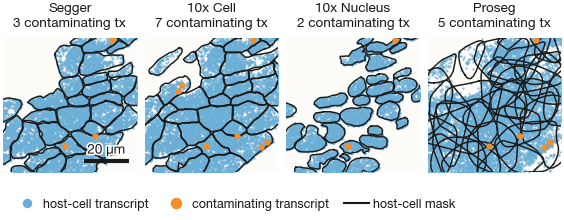

In [10]:
def masks_for(method, cells):
    if method in ("10x Cell", "10x Nucleus"):
        table = "cell_boundaries.parquet" if method == "10x Cell" else "nucleus_boundaries.parquet"
        return sg.io.read_xenium_boundaries(paths["xenium"] / table, cells=cells)
    return boundaries.cell_boundaries(tx.filter(pl.col(method).is_in(list(cells))), method, smoothing=2)


def cells_in(method, bbox, types=None, margin=4.0):
    x0, y0, x1, y1 = bbox
    cells = per_cell[method]
    keep = cells["x"].between(x0 - margin, x1 + margin) & cells["y"].between(y0 - margin, y1 + margin)
    if types is not None:
        keep &= cells["cell_type"].isin(types)
    return list(cells.index[keep])


fov_a = tx.filter(pl.col("x").is_between(bbox_a[0] - 20, bbox_a[2] + 20) & pl.col("y").is_between(bbox_a[1] - 20, bbox_a[3] + 20))
fig, axes = plt.subplots(2, len(METHODS), figsize=(122 * MM, 40 * MM), gridspec_kw={"wspace": 0.06, "height_ratios": [1, 0.18]})
for ax, method in zip(axes[0], METHODS):
    host = cells_in(method, bbox_a, HOST_TYPES)
    n = fov.contamination(ax, fov_a, method, masks_for(method, host), CONTAMINANTS, bbox_a)
    ax.set_title(f"{method}\n{n} contaminating tx", fontsize=6.5, linespacing=1.3)
fov.scale_bar(axes[0, 0], 20, color=sg.pl.style.INK)
legend = fig.add_subplot(axes[1, 0].get_gridspec()[1, :])
for ax in axes[1]:
    ax.remove()
fov.contamination_legend(legend)
sg.pl.save_panel(fig, OUT_DIR / "panel_a")

## Panel b: positive marker recall

The luminal epithelial cell of 10x Cell nearest to the centre of panel a with all four strongest luminal markers present within 10 µm; 30 × 30 µm field.

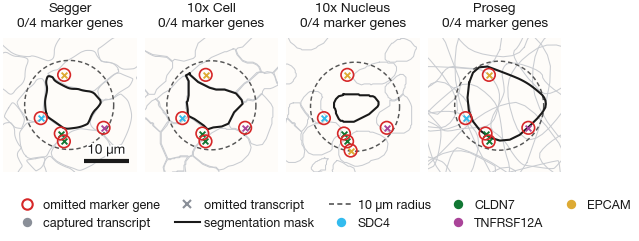

In [11]:
MARKER_GENES = positive["Luminal epithelial"][:4]
MARKERS = dict(zip(MARKER_GENES, ["#33BBEE", "#117733", "#AA4499", "#DDAA33"]))
center_a = np.array([(bbox_a[0] + bbox_a[2]) / 2, (bbox_a[1] + bbox_a[3]) / 2])
candidates = epi.assign(d=np.hypot(epi["x"] - center_a[0], epi["y"] - center_a[1])).sort_values("d")
marker_tx = tx.filter(pl.col("feature_name").is_in(MARKER_GENES)).select("feature_name", "x", "y")
for cell, row in candidates.iterrows():
    near = marker_tx.filter(((pl.col("x") - row["x"]) ** 2 + (pl.col("y") - row["y"]) ** 2) <= 100.0)
    if near.get_column("feature_name").n_unique() == len(MARKER_GENES):
        focal_10x = cell
        break
else:
    raise ValueError("no luminal epithelial cell has all four markers within 10 µm")
reference_cell = tx.filter(pl.col("10x Cell") == focal_10x)
center = tuple(reference_cell.select(pl.col("x").mean(), pl.col("y").mean()).row(0))
bbox_b = (center[0] - 15, center[1] - 15, center[0] + 15, center[1] + 15)
fov_b = tx.filter(pl.col("x").is_between(bbox_b[0] - 15, bbox_b[2] + 15) & pl.col("y").is_between(bbox_b[1] - 15, bbox_b[3] + 15))

fig, axes = plt.subplots(2, len(METHODS), figsize=(122 * MM, 44 * MM), gridspec_kw={"wspace": 0.06, "height_ratios": [1, 0.35]})
for ax, method in zip(axes[0], METHODS):
    focal = reference_cell.get_column(method).drop_nulls().mode().sort()[0]
    focal_center = tuple(tx.filter(pl.col(method) == focal).select(pl.col("x").mean(), pl.col("y").mean()).row(0))
    masks = masks_for(method, cells_in(method, bbox_b, margin=10) + [focal])
    recovered, available = fov.marker_recall(ax, fov_b, method, focal, focal_center, MARKERS, masks, bbox_b)
    ax.set_title(f"{method}\n{recovered}/{available} marker genes", fontsize=6.5, linespacing=1.3)
fov.scale_bar(axes[0, 0], 10, color=sg.pl.style.INK)
legend = fig.add_subplot(axes[1, 0].get_gridspec()[1, :])
for ax in axes[1]:
    ax.remove()
fov.marker_recall_legend(legend, MARKERS)
sg.pl.save_panel(fig, OUT_DIR / "panel_b")

## Panel c: sensitivity–specificity trade-off

PMR against specificity, as defined for Fig. 2c.

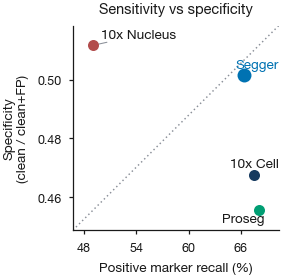

In [12]:
fig, ax = plt.subplots(figsize=(45 * MM, 45 * MM))
sg.pl.benchmark.tradeoff(ax, summary, "pmr", "specificity", xlabel="Positive marker recall (%)", ylabel="Specificity\n(clean / clean+FP)")
ax.set_title("Sensitivity vs specificity")
sg.pl.save_panel(fig, OUT_DIR / "panel_c")

## Panel d: per-method summary statistics

Cells after filtering, median transcripts per cell, percentage of transcripts assigned, spurious co-expression and cell-typing confidence; dashed lines mark the Segger value.
Error bars are the 25th–75th percentiles over cells.

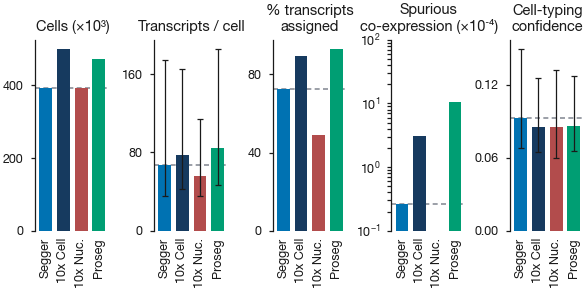

In [13]:
short = {"10x Nucleus": "10x Nuc."}
fig, axes = plt.subplots(1, 5, figsize=(120 * MM, 42 * MM), gridspec_kw={"wspace": 0.6})
sg.pl.benchmark.bars(axes[0], summary["cells"] / 1e3, title="Cells (×10³)", labels=short)
sg.pl.benchmark.bars(axes[1], summary["tx_per_cell"], summary["tx_per_cell_q1"], summary["tx_per_cell_q3"], title="Transcripts / cell", labels=short)
sg.pl.benchmark.bars(axes[2], summary["coverage"], title="% transcripts\nassigned", labels=short)
sg.pl.benchmark.bars(axes[3], summary["sce"] * 1e4, title="Spurious\nco-expression (×10⁻⁴)", log=True, labels=short)
sg.pl.benchmark.bars(axes[4], summary["confidence"], summary["confidence_q1"], summary["confidence_q3"], title="Cell-typing\nconfidence", labels=short)
sg.pl.save_panel(fig, OUT_DIR / "panel_d")

## Save as SpatialData

Transcripts with the assignment of every method, the cell x gene tables and the Segger and 10x outlines, in one SpatialData Zarr store (element names as in `segger export spatialdata`).

In [14]:
outlines = {
    "Segger": boundaries.cell_boundaries(tx, "Segger", cells=list(tables["Segger"].obs_names), smoothing=0, n_jobs=N_JOBS),
    "10x Cell": sg.io.read_xenium_boundaries(paths["xenium"] / "cell_boundaries.parquet", cells=list(tables["10x Cell"].obs_names)),
    "10x Nucleus": sg.io.read_xenium_boundaries(paths["xenium"] / "nucleus_boundaries.parquet", cells=list(tables["10x Nucleus"].obs_names)),
}
sdata = sg.io.write_spatialdata(OUT_DIR / "xenium_breast.zarr", tx.select("x", "y", "feature_name", *METHODS), tables, outlines, overwrite=True)
sdata

SpatialData object, with associated Zarr store: /Users/b450-admin/Desktop/Projects/Active/segger/release/segger-analysis/results/xenium_breast/xenium_breast.zarr
├── Points
│     └── 'transcripts': DataFrame with shape: (<Delayed>, 7) (2D points)
├── Shapes
│     ├── 'cell_boundaries_10x_cell': GeoDataFrame shape: (500936, 1) (2D shapes)
│     ├── 'cell_boundaries_10x_nucleus': GeoDataFrame shape: (391829, 1) (2D shapes)
│     └── 'cell_boundaries_segger': GeoDataFrame shape: (393589, 1) (2D shapes)
└── Tables
      ├── 'table_10x_cell': AnnData (500936, 5102)
      ├── 'table_10x_nucleus': AnnData (391829, 5102)
      ├── 'table_proseg': AnnData (472696, 5102)
      └── 'table_segger': AnnData (393589, 5102)
with coordinate systems:
    ▸ 'global', with elements:
        transcripts (Points), cell_boundaries_10x_cell (Shapes), cell_boundaries_10x_nucleus (Shapes), cell_boundaries_segger (Shapes)

## Software versions

In [15]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore")  # deprecation notices raised while reading package versions
    display(sc.logging.print_header())

Package,Version
spatialdata,0.4.0
pandas,2.2.3
anndata,0.11.4
matplotlib,3.10.1
numpy,2.2.5
polars,1.44.2
scanpy,1.11.4
geopandas,1.0.1
Component,Info
Python,"3.11.15 (main, May 8 2026, 18:24:56) [Clang 22.1.3 ]"
